In [2]:
# 1. Load dataset and basic checks
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("Housing (1).csv")

In [3]:
# Basic inspection
print("Shape of dataset:", df.shape)
print("\nDataset Info:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())



Shape of dataset: (545, 13)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

First 5 rows:
      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000 

In [4]:
# 2. Descriptive statistics
print("\nDescriptive Statistics:")
print(df.describe())



Descriptive Statistics:
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.000000  545.000000   
mean   4.766729e+06   5150.541284    2.965138    1.286239    1.805505   
std    1.870440e+06   2170.141023    0.738064    0.502470    0.867492   
min    1.750000e+06   1650.000000    1.000000    1.000000    1.000000   
25%    3.430000e+06   3600.000000    2.000000    1.000000    1.000000   
50%    4.340000e+06   4600.000000    3.000000    1.000000    2.000000   
75%    5.740000e+06   6360.000000    3.000000    2.000000    2.000000   
max    1.330000e+07  16200.000000    6.000000    4.000000    4.000000   

          parking  
count  545.000000  
mean     0.693578  
std      0.861586  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      1.000000  
max      3.000000  


In [5]:
# 3. Missing value percentage
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": missing_percent
}).sort_values(by="Missing_Percentage", ascending=False)

print("\nMissing Value Percentage:")
print(missing_df)



Missing Value Percentage:
                  Missing_Count  Missing_Percentage
price                         0                 0.0
area                          0                 0.0
bedrooms                      0                 0.0
bathrooms                     0                 0.0
stories                       0                 0.0
mainroad                      0                 0.0
guestroom                     0                 0.0
basement                      0                 0.0
hotwaterheating               0                 0.0
airconditioning               0                 0.0
parking                       0                 0.0
prefarea                      0                 0.0
furnishingstatus              0                 0.0


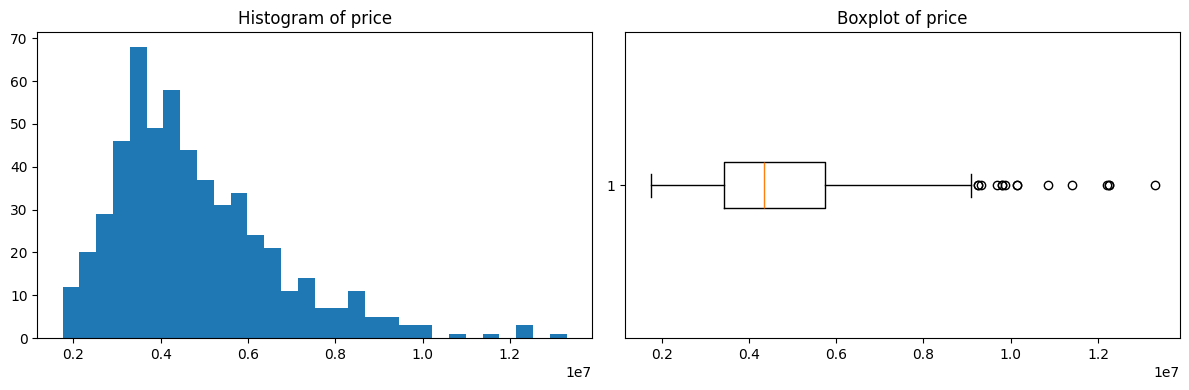

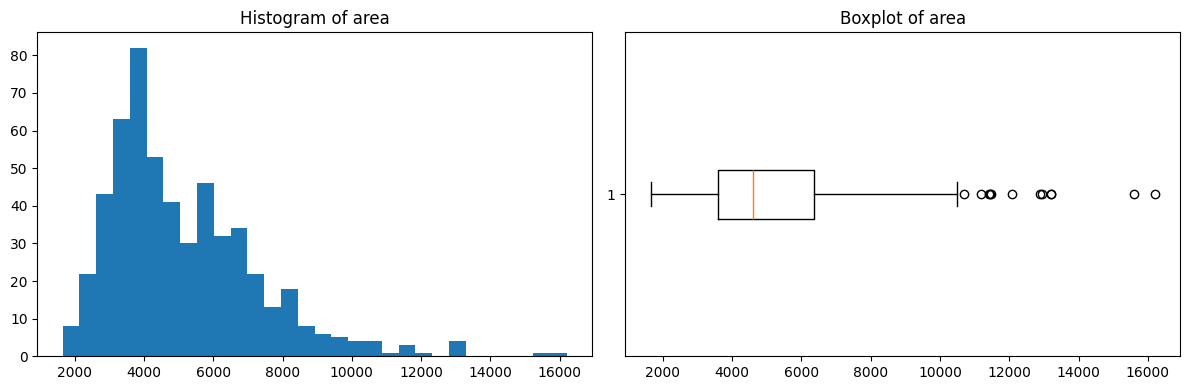

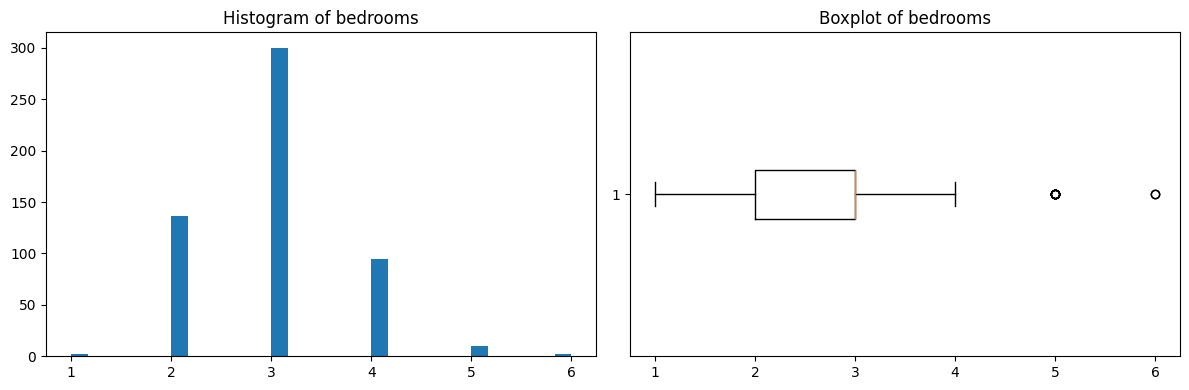

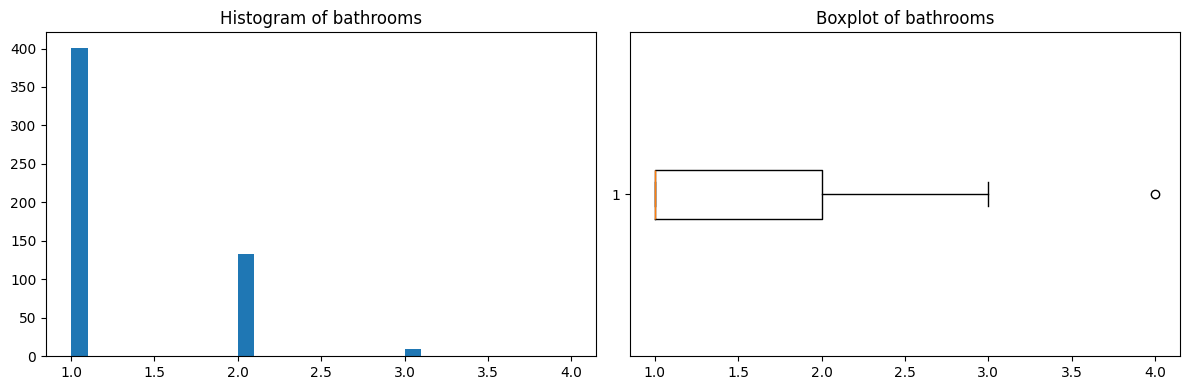

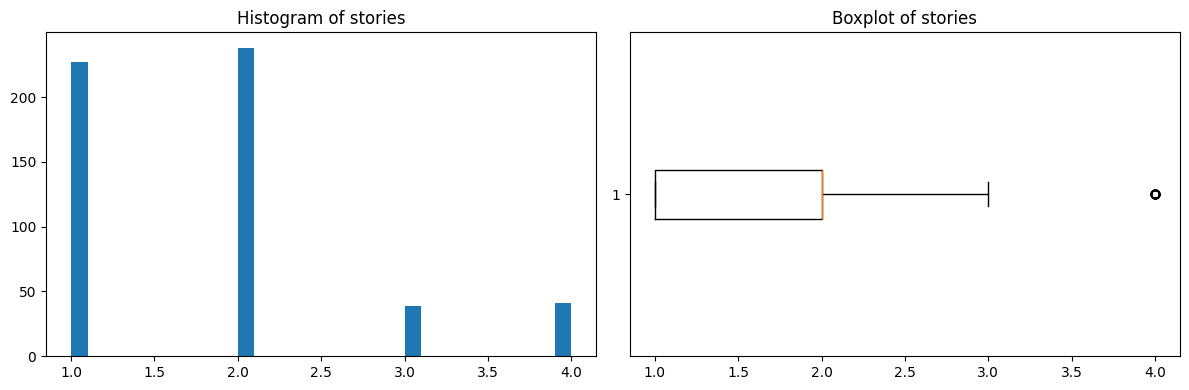

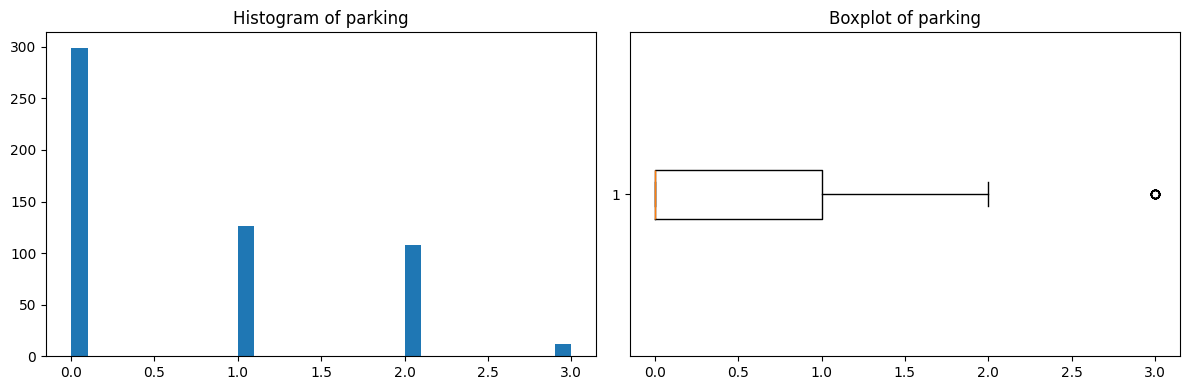

In [6]:

# 4. Plot distributions (Histogram + Boxplot)
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(12, 4))

    # Histogram
    plt.subplot(1, 2, 1)
    plt.hist(df[col], bins=30)
    plt.title(f"Histogram of {col}")

    # Boxplot
    plt.subplot(1, 2, 2)
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")

    plt.tight_layout()
    plt.show()

In [7]:
# 5. Detect outliers using IQR
outlier_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_summary[col] = outliers

print("\nOutlier Count per Column:")
print(pd.DataFrame.from_dict(outlier_summary, orient="index", columns=["Outlier_Count"]))


Outlier Count per Column:
           Outlier_Count
price                 15
area                  12
bedrooms              12
bathrooms              1
stories               41
parking               12


In [8]:
# 6. Create outlier flag column (example: for all numeric columns)
df["Outlier_Flag"] = 0

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df.loc[(df[col] < lower_bound) | (df[col] > upper_bound), "Outlier_Flag"] = 1


In [9]:
# 7. Handle outliers using capping (winsorization)
df_capped = df.copy()

for col in numeric_cols:
    Q1 = df_capped[col].quantile(0.25)
    Q3 = df_capped[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_capped[col] = np.where(df_capped[col] < lower_bound, lower_bound, df_capped[col])
    df_capped[col] = np.where(df_capped[col] > upper_bound, upper_bound, df_capped[col])



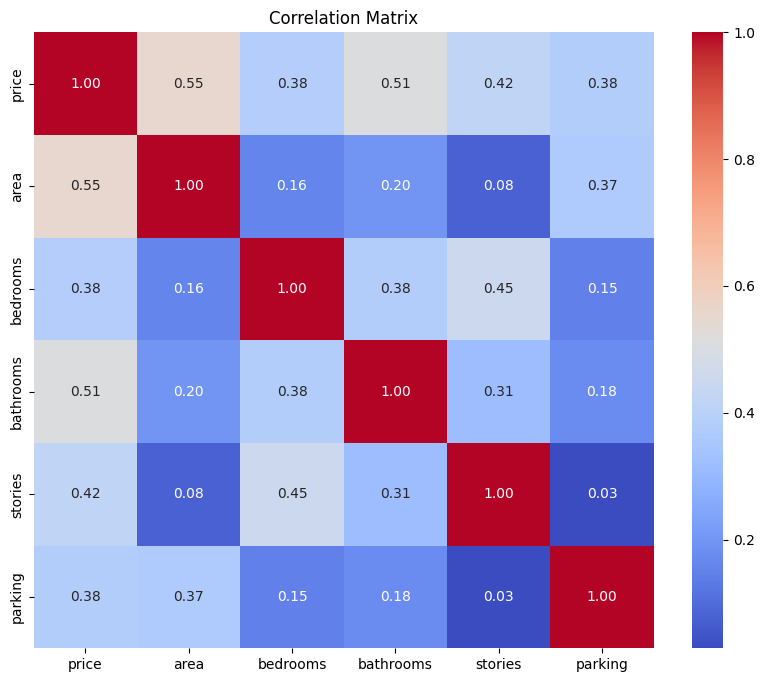


Top Correlated Feature Pairs:
price      area         0.553876
area       price        0.553876
bathrooms  price        0.508576
price      bathrooms    0.508576
stories    bedrooms     0.449893
bedrooms   stories      0.449893
stories    price        0.415874
price      stories      0.415874
           bedrooms     0.381802
bedrooms   price        0.381802
dtype: float64


In [10]:
# 8. Correlation matrix
corr_matrix = df_capped[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

# Top correlations (excluding self-correlation)
corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
top_correlations = corr_pairs[corr_pairs < 1].head(10)

print("\nTop Correlated Feature Pairs:")
print(top_correlations)


In [11]:
# 9. Export cleaned dataset
df_capped.to_csv("housing_cleaned.csv", index=False)
print("\nCleaned dataset exported as housing_cleaned.csv")


Cleaned dataset exported as housing_cleaned.csv
